<table width="100%">
  <tr>
    <td align="left" valign="middle" width="100%">
      <img src="../docs/assets/logo_bristol.png" alt="University of Bristol" width="200" />
    </td>
    <td align="right" valign="middle" width="100%">
      <img src="../docs/assets/logo_ufpe.png" alt="UFPE" width="130" />
      &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
      <img src="../docs/assets/logo_kunumi.png" alt="Kunumi" width="150" />
      &nbsp;&nbsp;
    </td>
  </tr>
</table>

---

In [1]:
from nb_utils import set_root

PROJECT_ROOT = set_root(level=2)

# Section 2: Binary IRT, 1PL Intuition, and 2PL ICCs

In IRT, respondents have latent ability and items have latent parameters. This gives us a way to ask not only *who performs better*, but also *which items separate stronger and weaker respondents*.


## Learning Goals

By the end of this section, participants should be able to:

- interpret ability, difficulty, and discrimination;
- read an item characteristic curve (ICC);
- distinguish the 1PL intuition from the more flexible 2PL model;
- explain how IRT reweights performance through item difficulty.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

from utils.handson import binary_irt_probability, make_binary_item_bank, plot_binary_iccs


## Step 1: Start with a tiny item bank

We use three stylized items so the class can read the curves quickly.


In [3]:
item_bank = make_binary_item_bank()
item_bank


,item,difficulty,discrimination
0,easy_item,0.1,0.8
1,medium_item,0.5,1.2
2,hard_item,0.9,1.6


## Step 2: 1PL-style intuition

If we force every item to have the same discrimination, only difficulty changes. The curves shift left or right, but keep the same slope.


$$
x_{ij} \sim Bern(p_{ij})
$$

where

$$
E[x_{ij} | \theta_i, \delta_j, a_j] = p_{ij} = \frac{1}{1 + e^{-a_j \cdot (\theta_i - \delta_j)}}
$$

For 1PL case, it will be consider a<sub>j</sub>=1. So, we have:

$$
E[x_{ij} | \theta_i, \delta_j, a_j] = \frac{1}{1 + e^{-(\theta_i - \delta_j)}}
$$

In [4]:
theta = np.linspace(0.01, 0.99, 300)
one_pl_bank = item_bank.copy()
one_pl_bank['discrimination'] = 1.0

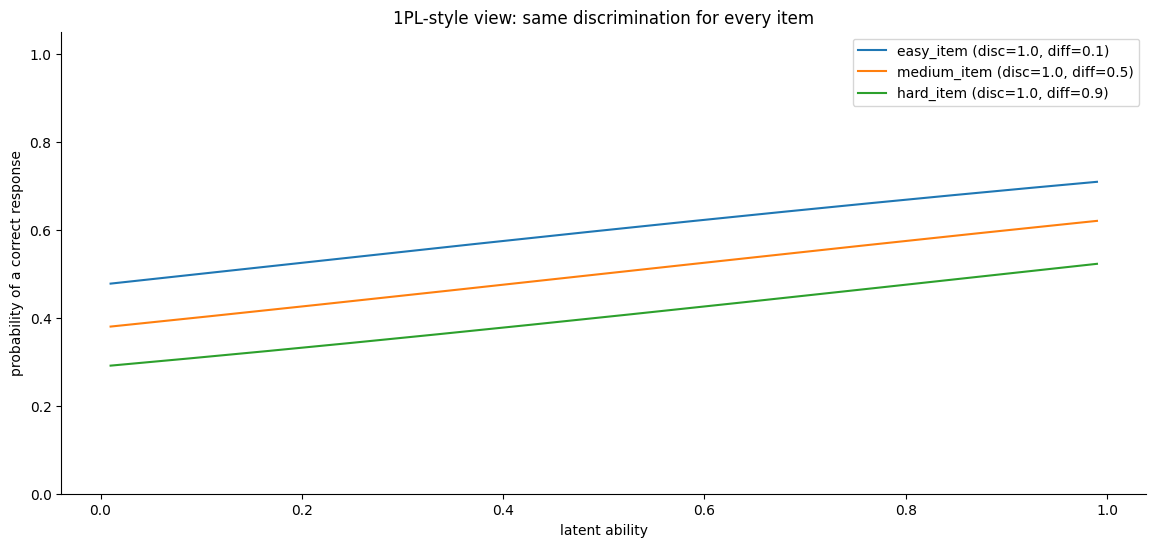

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
ax = plot_binary_iccs(
    one_pl_bank,
    theta=theta,
    title='1PL-style view: same discrimination for every item',
    ax = ax
)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Step 3: 2PL curves

In 2PL, each item also has its own discrimination. This changes the slope of the ICC and tells us how sharply the item separates low- and high-ability respondents.


$$
x_{ij} \sim Bern(p_{ij})
$$

where

$$
E[x_{ij} | \theta_i, \delta_j, a_j] = p_{ij} = \frac{1}{1 + e^{-a_j \cdot (\theta_i - \delta_j)}}
$$

In [6]:
item_bank_neg = make_binary_item_bank(
    [
        {"item": "easy_item", "difficulty": 0.1, "discrimination": -30},
        {"item": "medium_item", "difficulty": 0.5, "discrimination": -30},
        {"item": "hard_item", "difficulty": 0.9, "discrimination": -30},
    ]
)
item_bank_pos = make_binary_item_bank(
    [
        {"item": "easy_item", "difficulty": 0.1, "discrimination": 30},
        {"item": "medium_item", "difficulty": 0.5, "discrimination": 30},
        {"item": "hard_item", "difficulty": 0.9, "discrimination": 30}
    ]
)


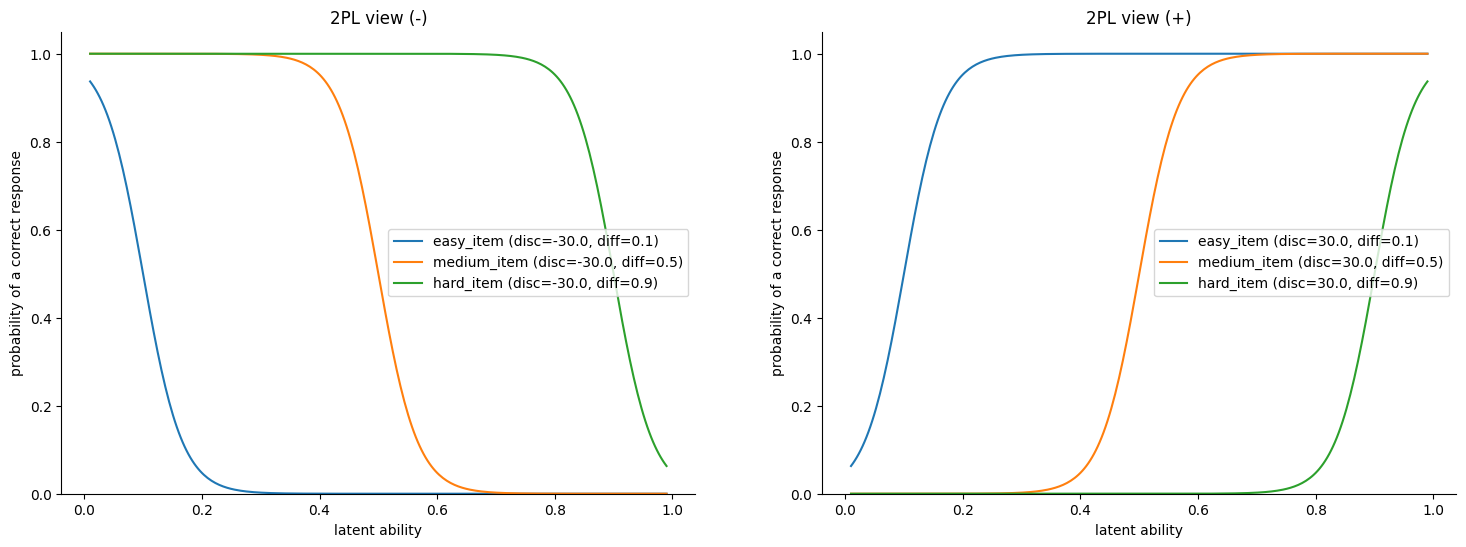

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
plot_binary_iccs(
    item_bank_neg,
    theta=theta,
    title='2PL view (-)',
    ax = ax[0]
)
plot_binary_iccs(
    item_bank_pos,
    theta=theta,
    title='2PL view (+)',
    ax = ax[1]
)
for _ax in ax:
    _ax.spines[["top", "right"]].set_visible(False)
plt.show()


In [8]:
item_bank = pd.concat([item_bank_neg, item_bank_pos], ignore_index=True)

In [9]:
abis = [
    {"name": "model_1", "ability": 0.1},
    {"name": "model_2", "ability": 0.5},
    {"name": "model_3", "ability": 0.9}
]
diff_disc = [
    {"item": "item_1", "difficulty": 0.1, "discrimination": 30},
    {"item": "item_2", "difficulty": 0.5, "discrimination": 30},
    {"item": "item_3", "difficulty": 0.9, "discrimination": 30},
    {"item": "item_4", "difficulty": 0.1, "discrimination": -30},
    {"item": "item_5", "difficulty": 0.5, "discrimination": -30},
    {"item": "item_6", "difficulty": 0.9, "discrimination": -30}
]
values = np.zeros(
    (len(diff_disc), len(abis))
)
for i, abi in enumerate(abis):
    for j, row in enumerate(diff_disc):
        p = binary_irt_probability(abi["ability"], row["difficulty"], row["discrimination"])
        values[j, i] = p
pij = pd.DataFrame(
    values,
    columns = [abi["name"] for abi in abis],
    index = [row["item"] for row in diff_disc]
)
pij.round(4)

,model_1,model_2,model_3
item_1,0.5,1.0,1.0
item_2,0.0,0.5,1.0
item_3,0.0,0.0,0.5
item_4,0.5,0.0,0.0
item_5,1.0,0.5,0.0
item_6,1.0,1.0,0.5


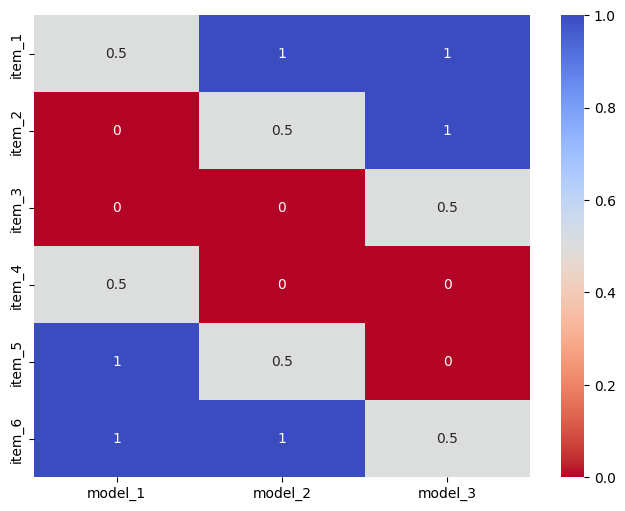

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pij.round(4), annot=True, cmap='coolwarm_r', ax=ax)
plt.show()

## Step 4: Hold difficulty fixed and vary discrimination

This is the cleanest way to explain what the `a_j` parameter does.


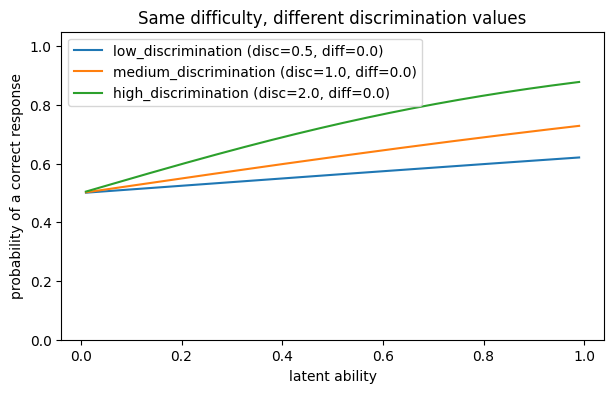

In [11]:
discrimination_demo = pd.DataFrame(
    [
        {'item': 'low_discrimination', 'difficulty': 0.0, 'discrimination': 0.5},
        {'item': 'medium_discrimination', 'difficulty': 0.0, 'discrimination': 1.0},
        {'item': 'high_discrimination', 'difficulty': 0.0, 'discrimination': 2.0},
    ]
)

ax = plot_binary_iccs(discrimination_demo, theta=theta, title='Same difficulty, different discrimination values')
plt.show()


## Reading the Curves

- Higher difficulty moves the curve to the right.
- Higher discrimination makes the transition sharper.
- When `theta = difficulty`, the success probability is around `0.5`.
- ICCs describe *probability of success*, not a raw score.


## Bridge to Section 3

Logistic ICCs are excellent for intuition, but some AI evaluation settings use **continuous responses** rather than binary right-or-wrong outcomes. That motivates Beta-family IRT models, especially Beta4-IRT.
